In [1]:
import numpy as np
from sklearn import metrics
import os
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import roc_curve, roc_auc_score
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset
import pickle

In [3]:
y_true = [0] * 91 + [1] * 74

In [4]:
# place raw data here

y_pred = [
    2.34, 0.84, 3.81, 9.67, 3.35, 1.85, 3.53, 4.53, 1.49, 0.31,
    2.67, 1.75, 2.68, 1.26, 1.49, 2.91, 1.12, 3.06, 3.25, 1.74,
    1.78, 3.53, 3.04, 1.45, 3.77, 1.57, 0.34, 0.94, 26.6, 9.88,
    4.00, 2.44, 1.80, 1.99, 3.49, 4.01, 3.78, 7.9, 1.78, 1.56,
    1.16, 8.29, 2.64, 2.40, 4.41, 2.84, 1.43, 2.69, 16.6, 3.21,
    14.5, 5.41, 2.36, 7.5, 7.2, 3.10, 0.85, 7.66, 5.80, 1.53,
    0.36, 1.31, 3.56, 2.50, 3.96, 7.64, 4.91, 2.27, 1.04, 8.61,
    10.10, 0.67, 7.11, 0.17, 0.25, 0.15, 0.00, 1.38, 0.11, 0.20,
    0.25, 0.42, 0.90, 0.19, 1.10, 0.47, 0.21, 0.00, 0.52, 0.00,
    1.03, 48.0, 51.5, 25.4, 31.7, 33.7, 32.0, 26.5, 67.7, 37.0,
    82.6, 69.6, 72.9, 30.3, 65.8, 39.1, 42.9, 55.7, 73.3, 66.1,
    38.1, 29.5, 56.3, 39.7, 39.6, 26.9, 51.3, 72.0, 81.0, 22.0,
    34.8, 31.0, 24.8, 73.9, 72.9, 61.2, 73.7, 64.2, 79.9, 17.5,
    60.2, 43.1, 20.0, 15.1, 62.3, 82.2, 79.0, 47.6, 52.3, 92.3,
    82.5, 61.3, 15.3, 83.3, 78.9, 33.4, 53.0, 49.6, 28.8, 36.1,
    44.4, 34.0, 31.2, 40.3, 15.3, 29.9, 62.3, 47.7, 35.2, 48.6,
    34.5, 62.5, 64.5, 28.8, 31.3
]
print(len(y_pred))

165


In [5]:
y_true_arr = np.asarray(y_true, dtype=int)


y_pred_arr = np.asarray(y_pred, dtype=float)
y_pred_arr = y_pred_arr / 100.0

fpr_list, tpr_list, thresholds = roc_curve(y_true_arr, y_pred_arr)
auc_score = roc_auc_score(y_true_arr, y_pred_arr)

In [43]:
def plot_multi_roc(
        results_dict,
        figsize=(6, 5),
        colors=None,
        inset_bounds=(0.70, 0.60, 0.26, 0.26),  # [left, bottom, width, height]
        zoom_xlim=(0, 0.1),
        zoom_ylim=(0.9, 1.0),
        show_std=True,
        label_fontsize=18,
        tick_fontsize=12,
        inset_tick_fontsize=10):
    """
    Plot multiple ROC curves with optional σ-bands and a zoom inset.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    if colors is None:
        colors = ['#8b91c1', '#d9a9cd', '#424874', '#e6d3ae']

    fig, ax = plt.subplots(figsize=figsize)

    # Main plot
    for idx, (name, res) in enumerate(results_dict.items()):
        c = colors[idx % len(colors)]
        ax.plot(
            res['mean_fpr'], res['mean_tpr'],
            lw=2, alpha=0.8, color=c,
            label=f'{name} Overall AUC = {res["mean_auc"]:.4f}'
        )

        if show_std and 'std_tpr' in res:
            upper = np.minimum(res['mean_tpr'] + res['std_tpr'], 1)
            lower = np.maximum(res['mean_tpr'] - res['std_tpr'], 0)
            ax.fill_between(res['mean_fpr'], lower, upper, color=c, alpha=0.2)

    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('Sensitivity', fontsize=label_fontsize)
    ax.set_ylabel('1 - Specificity', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.legend(loc="lower right", fontsize=label_fontsize)

    # Inset — exact placement
    axins = ax.inset_axes(inset_bounds)

    for idx, (name, res) in enumerate(results_dict.items()):
        c = colors[idx % len(colors)]
        axins.plot(res['mean_fpr'], res['mean_tpr'], lw=2, color=c)

        if show_std and 'std_tpr' in res:
            upper = np.minimum(res['mean_tpr'] + res['std_tpr'], 1)
            lower = np.maximum(res['mean_tpr'] - res['std_tpr'], 0)
            axins.fill_between(res['mean_fpr'], lower, upper, color=c, alpha=0.2)

    axins.set_xlim(*zoom_xlim)
    axins.set_ylim(*zoom_ylim)

    axins.set_xticks([0.0, 0.05, 0.1])
    axins.set_yticks([0.9, 0.95, 1.0])
    axins.minorticks_off()
    axins.tick_params(axis='both', labelsize=inset_tick_fontsize, pad=1)

    plt.tight_layout()
    return fig, ax, axins

(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Sensitivity', ylabel='1 - Specificity'>,
 <Axes: label='inset_axes'>)

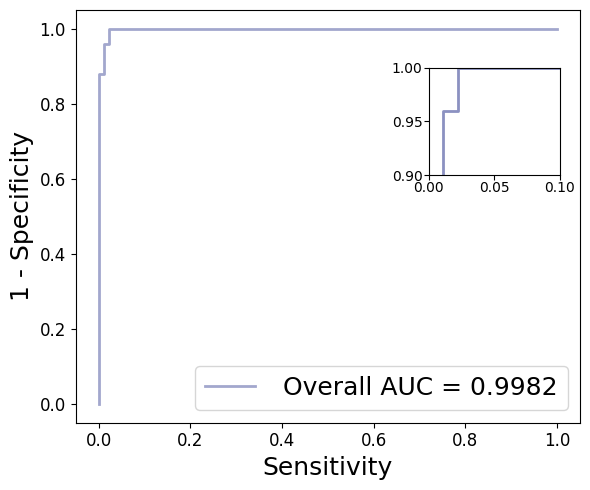

In [44]:
results_dict = {"": {
            'mean_fpr': fpr_list,
            'mean_tpr': tpr_list,
            'mean_auc': auc_score}
            }

plot_multi_roc(results_dict=results_dict, zoom_xlim=(0, 0.1), zoom_ylim=(0.9,1.0))